<a href="https://colab.research.google.com/github/ThiPi93/BigDataSenacNI/blob/main/Meu_codigo_aula15_bigdata_uc2_05_01_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import polars as pl

pl.scan_csv(
    "/content/title.ratings.tsv",
    separator="\t",
    null_values="\\N",
    encoding="utf8",
    quote_char=None,          # ← ESSENCIAL
    truncate_ragged_lines=True,
    ignore_errors=True,
    infer_schema_length=50_000
).sink_parquet(
    "/content/title_ratings_POLARS.parquet"
)


In [2]:
import polars as pl

pl.scan_csv(
    "/content/title.basics.tsv",
    separator="\t",
    null_values="\\N",
    encoding="utf8",
    quote_char=None,          # ← ESSENCIAL
    truncate_ragged_lines=True,
    ignore_errors=True,
    infer_schema_length=200_000
).sink_parquet(
    "/content/title_basics_POLARS.parquet"
)


In [3]:
titles = pl.scan_parquet("/content/title_basics_POLARS.parquet")
ratings = pl.scan_parquet("/content/title_ratings_POLARS.parquet")

df_final = (
    titles
    .join(ratings, on="tconst", how="inner")
    .select([
        "tconst",
        "primaryTitle",
        "titleType",
        "startYear",
        "averageRating",
        "numVotes"
    ])
    .collect()
)

df_final.head()


tconst,primaryTitle,titleType,startYear,averageRating,numVotes
str,str,str,i64,f64,i64
"""tt0000001""","""Carmencita""","""short""",1894,5.7,2185
"""tt0000002""","""Le clown et ses chiens""","""short""",1892,5.5,306
"""tt0000003""","""Poor Pierrot""","""short""",1892,6.4,2270
"""tt0000004""","""Un bon bock""","""short""",1892,5.2,196
"""tt0000005""","""Blacksmith Scene""","""short""",1893,6.2,3010


### Métricas: Média, Mediana, Moda, Variância, Desvio Padrão, Amplitude

In [4]:
import polars as pl

titles = pl.scan_parquet("/content/title_basics_POLARS.parquet")
ratings = pl.scan_parquet("/content/title_ratings_POLARS.parquet")

inicial = (
    titles
    .join(ratings, on="tconst", how="inner")
    .filter(pl.col("averageRating").is_not_null())
)


In [5]:
metricas1 = (
    inicial
    .select([
        pl.col("averageRating").mean().alias("Média"),
        pl.col("averageRating").median().alias("Mediana"),
        pl.col("averageRating").mode().first().alias("Moda"),
        pl.col("averageRating").var().alias("Variância"),
        pl.col("averageRating").std().alias("Desvio_Padrão"),
        (pl.col("averageRating").max() - pl.col("averageRating").min())
            .alias("Amplitude_Total")
    ])
    .collect()
)

print("\n--- Estatísticas Descritivas (Average Rating) ---")
display(metricas1)



--- Estatísticas Descritivas (Average Rating) ---


Média,Mediana,Moda,Variância,Desvio_Padrão,Amplitude_Total
f64,f64,f64,f64,f64,f64
6.154421,6.2,6.4,1.197637,1.094366,8.9


### Forma e Posição: Assimetria, Curtose e Quartis

In [6]:
metricas2 = (
    inicial
    .select([
        pl.col("averageRating").quantile(0.25).alias("Q1"),
        pl.col("averageRating").quantile(0.50).alias("Q2 (Mediana)"),
        pl.col("averageRating").quantile(0.75).alias("Q3"),
        pl.col("averageRating").skew().alias("Assimetria"),
        pl.col("averageRating").kurtosis().alias("Curtose")
    ])
    .collect()
)

print("\n--- Quartis e Forma da Distribuição (Average Rating) ---")
display(metricas2)


assimetria = metricas2["Assimetria"][0]

print(f"\nInterpretação da Assimetria ({assimetria:.2f}):")

if -0.5 <= assimetria <= 0.5:
    print("-> Distribuição aproximadamente simétrica (notas bem balanceadas)")
elif assimetria > 0.5:
    print("-> Assimetria positiva (cauda à direita: poucos filmes com notas muito altas)")
else:
    print("-> Assimetria negativa (cauda à esquerda: poucos filmes com notas muito baixas)")



--- Quartis e Forma da Distribuição (Average Rating) ---


Q1,Q2 (Mediana),Q3,Assimetria,Curtose
f64,f64,f64,f64,f64
5.5,6.2,6.9,-0.44776,0.540077



Interpretação da Assimetria (-0.45):
-> Distribuição aproximadamente simétrica (notas bem balanceadas)


###Outliers

In [7]:
Q1 = metricas2["Q1"][0]
Q3 = metricas2["Q3"][0]
IQR = Q3 - Q1

limite_inferior = Q1 - (1.5 * IQR)
limite_superior = Q3 + (1.5 * IQR)

print(
    f"\nLimites para Outliers (Average Rating): "
    f"Inferior = {limite_inferior:.2f} | Superior = {limite_superior:.2f}"
)

outliers = (
    inicial
    .filter(
        (pl.col("averageRating") < limite_inferior) |
        (pl.col("averageRating") > limite_superior)
    )
    .select([
        pl.col("primaryTitle"),
        pl.col("runtimeMinutes"),
        pl.col("averageRating")
    ])
    .collect()
)

print(f"Quantidade de obras consideradas outliers: {outliers.height}")
print("Exemplos de valores discrepantes:")
display(outliers.head())



Limites para Outliers (Average Rating): Inferior = 3.40 | Superior = 9.00
Quantidade de obras consideradas outliers: 1348
Exemplos de valores discrepantes:


primaryTitle,runtimeMinutes,averageRating
str,i64,f64
"""Batteuse à vapeur""",null,3.3
"""A Chegada do Comboio Inaugural…",null,2.9
"""Uma Corrida de Touros no Campo…",null,3.0
"""Dessinateur express""",null,3.3
"""Dessinateur: Chamberlain""",null,3.1


### Visualização

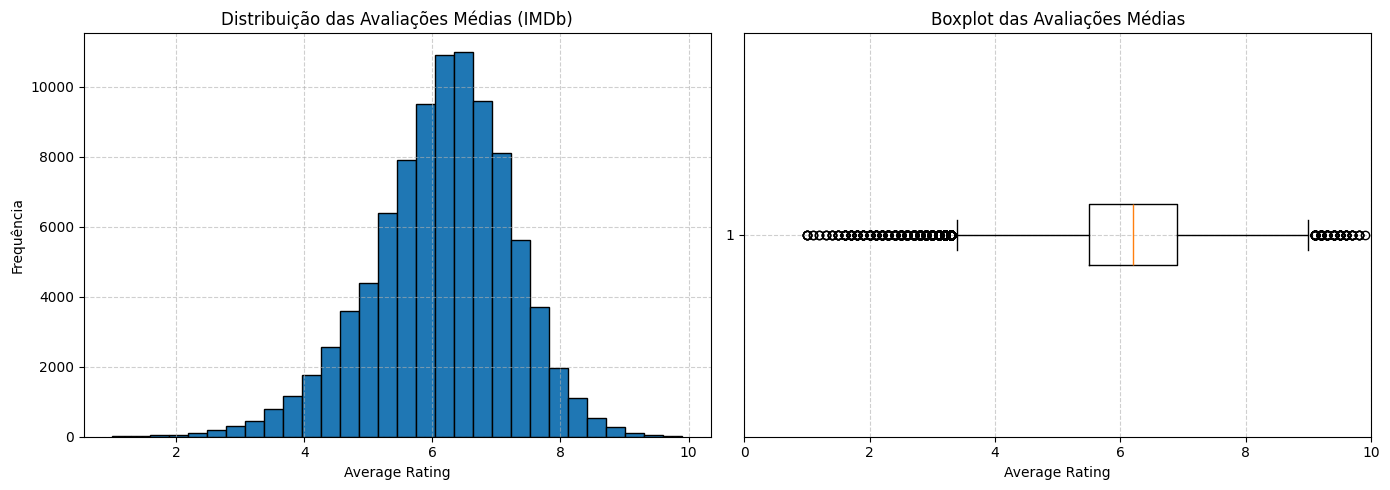

In [8]:
import matplotlib.pyplot as plt

# Coletando os dados
visual = (
    inicial
    .select("averageRating")
    .drop_nulls()
    .collect()
    .to_series()
)

plt.figure(figsize=(14, 5))

# =========================
# Histograma
# =========================
plt.subplot(1, 2, 1)
plt.hist(
    visual,
    bins=30,
    edgecolor='black'  # contorno dos bins
)
plt.title("Distribuição das Avaliações Médias (IMDb)")
plt.xlabel("Average Rating")
plt.ylabel("Frequência")
plt.grid(
    True,
    linestyle='--',
    alpha=0.6
)

# =========================
# Boxplot
# =========================
plt.subplot(1, 2, 2)
plt.boxplot(
    visual,
    vert=False
)
plt.title("Boxplot das Avaliações Médias")
plt.xlabel("Average Rating")
plt.xlim(0, 10)  # escala fixa do IMDb
plt.grid(
    True,
    linestyle='--',
    alpha=0.6
)

plt.tight_layout()
plt.show()



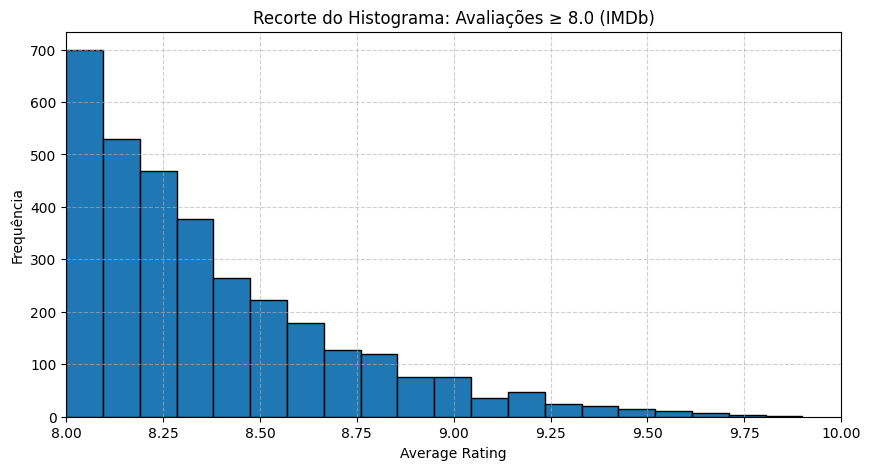

In [9]:
import matplotlib.pyplot as plt
import polars as pl

# Recorte: filmes muito bem avaliados (rating >= 8)
visual_superiores = (
    inicial
    .filter(pl.col("averageRating") >= 8)
    .select("averageRating")
    .drop_nulls()
    .collect()
    .to_series()
)

plt.figure(figsize=(10, 5))

plt.hist(
    visual_superiores,
    bins=20,
    edgecolor="black"
)

plt.title("Recorte do Histograma: Avaliações ≥ 8.0 (IMDb)")
plt.xlabel("Average Rating")
plt.ylabel("Frequência")

plt.grid(
    True,
    linestyle="--",
    alpha=0.6
)

plt.xlim(8, 10)  # foco apenas na cauda superior
plt.show()


###Correlação de Pearson

Para calcular a Correlação de Pearson, é necessário trabalhar com duas variáveis numéricas contínuas, pois o objetivo é medir o grau de relação linear entre elas.

No contexto deste projeto, o foco deixa de ser benefícios financeiros e passa a ser obras audiovisuais. Assim, a análise é feita no nível do filme, considerando duas variáveis diretamente comparáveis:

- Duração do filme (runtimeMinutes)

- Nota média no IMDb (averageRating)

Essas variáveis permitem investigar se existe algum padrão entre tempo de duração e avaliação do público.

🎯 Pergunta de Análise

Filmes mais longos tendem a receber notas mais altas no IMDb, notas mais baixas, ou não existe uma relação clara entre duração e avaliação?

In [10]:
import polars as pl

# 1. Criar faixas de duração (granularidade analítica)
df_faixas = (
    inicial
    .filter(
        (pl.col("titleType") == "movie") &
        (pl.col("runtimeMinutes").is_not_null()) &
        (pl.col("averageRating").is_not_null())
    )
    .with_columns(
        pl.when(pl.col("runtimeMinutes") < 81)
          .then(pl.lit("Curto (até 80 min)"))
        .when(pl.col("runtimeMinutes") < 121)
          .then(pl.lit("Médio (81–120 min)"))
        .when(pl.col("runtimeMinutes") < 151)
          .then(pl.lit("Longo (121–150 min)"))
        .otherwise(pl.lit("Muito longo (150+ min)"))
        .alias("faixa_duracao")
    )
)

# 2. Agregar por faixa de duração
df_agregado = (
    df_faixas
    .group_by("faixa_duracao")
    .agg([
        pl.len().alias("Qtd_Filmes"),
        pl.col("averageRating").mean().alias("Nota_Media")
    ])
)

# 3. Calcular Correlação de Pearson
correlacao = df_agregado.select(
    pl.corr("Qtd_Filmes", "Nota_Media", method="pearson").alias("r")
).collect()

r = correlacao["r"][0]
r2 = r ** 2

print("\n--- Análise de Correlação: Duração x Nota IMDb ---")
print(f"Coeficiente de Pearson (r): {r:.4f}")
print(f"Coeficiente de Determinação (r²): {r2:.4f}")

# 4. Interpretação automática
if abs(r) < 0.3:
    print("Conclusão: Correlação FRACA. A duração não influencia significativamente a nota média.")
elif abs(r) > 0.7:
    print("Conclusão: Correlação FORTE. A duração tem forte relação com a avaliação média.")
else:
    print("Conclusão: Correlação MODERADA. Existe alguma relação entre duração e nota.")



--- Análise de Correlação: Duração x Nota IMDb ---
Coeficiente de Pearson (r): -0.7919
Coeficiente de Determinação (r²): 0.6272
Conclusão: Correlação FORTE. A duração tem forte relação com a avaliação média.


### Gráfico de Dispersão

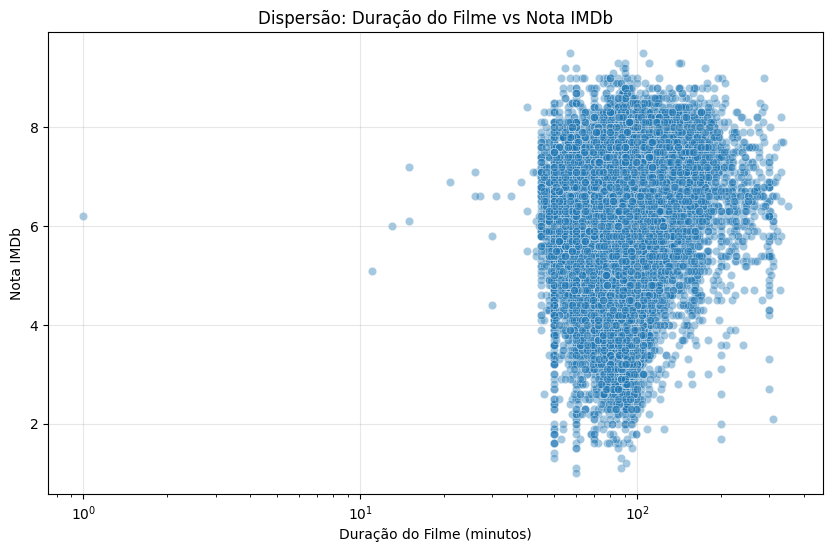

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

# 1. Preparar os dados para visualização
df_scatter = (
    inicial
    .filter(
        (pl.col("titleType") == "movie") &
        (pl.col("runtimeMinutes").is_not_null()) &
        (pl.col("averageRating").is_not_null()) &
        (pl.col("runtimeMinutes") <= 350)
    )
    .select([
        "runtimeMinutes",
        "averageRating"
    ])
    .collect()
)


# 2. Criar o gráfico de dispersão
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_scatter.to_pandas(),
    x="runtimeMinutes",
    y="averageRating",
    alpha=0.4
)

plt.title("Dispersão: Duração do Filme vs Nota IMDb")
plt.xlabel("Duração do Filme (minutos)")
plt.ylabel("Nota IMDb")
##plt.ylim(0, 10)                 # Escala natural do IMDb
plt.xscale('log')
plt.grid(True, alpha=0.3)

plt.show()


##Classificação por Método de Correlação

Para analisar a relação entre a duração de um filme (runtimeMinutes) e sua avaliação média no IMDb (averageRating), o Polars oferece dois métodos estatísticos principais: Pearson e Spearman. Cada um responde a perguntas analíticas diferentes.

###A. Correlação de Pearson ($r$)

- O que mede: Relações lineares entre duas variáveis numéricas.

- Interpretação no contexto do projeto:
Avalia se filmes mais longos tendem, em média, a receber notas proporcionalmente maiores ou menores no IMDb, assumindo uma relação próxima de uma linha reta.

Suposições estatísticas:

- Relação linear entre as variáveis

- Distribuição aproximadamente normal

- Limitação importante:
É altamente sensível a outliers. Filmes com durações extremamente longas (ex.: 600, 900 ou 1400 minutos), comuns em bases amplas como o IMDb, podem distorcer o coeficiente, sugerindo correlação onde não há um padrão real no cinema comercial.

- Quando usar neste projeto:
Após aplicar filtros de duração (ex.: até 300–350 minutos), reduzindo o efeito de obras atípicas.

###B. Correlação de Spearman ($\rho$)

- O que mede: Relações monotônicas baseadas em ranking.

- Monotônica:
Sempre que a duração aumenta, a nota tende a aumentar ou diminuir, mesmo que essa relação não seja linear.

- Interpretação no contexto do projeto:
Indica se filmes mais longos costumam ocupar posições mais altas ou mais baixas no ranking de notas, independentemente da diferença exata de minutos.

- Vantagem principal:
É robusta a outliers. Um filme com 1200 minutos será tratado apenas como “o mais longo”, sem peso excessivo sobre o resultado.

- Quando usar neste projeto:
Em análises exploratórias iniciais ou quando se deseja avaliar tendência geral sem excluir filmes muito longos.

In [ ]:
import polars as pl

# Garantir apenas filmes válidos para a análise
analise_correlacao = (
    inicial
    .filter(
        (pl.col("titleType") == "movie") &
        (pl.col("runtimeMinutes").is_not_null()) &
        (pl.col("averageRating").is_not_null())
    )
    .select([
        pl.corr("runtimeMinutes", "averageRating", method="pearson").alias("Pearson"),
        pl.corr("runtimeMinutes", "averageRating", method="spearman").alias("Spearman")
    ])
    .collect()
)

print("\n--- Correlação: Duração do Filme x Nota IMDb ---")
display(analise_correlacao)



--- Correlação: Duração do Filme x Nota IMDb ---


Pearson,Spearman
f64,f64
0.175588,0.194864


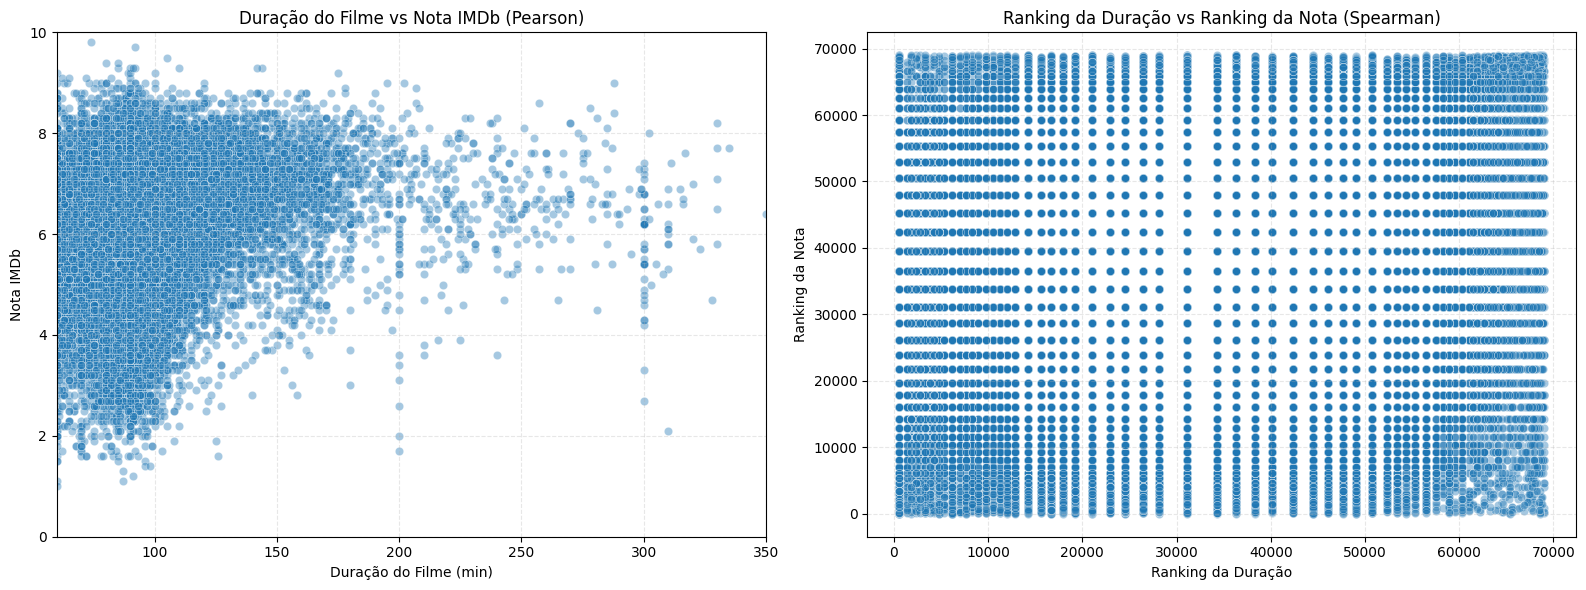

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar os dados: filtrar apenas filmes válidos e criar rankings
df_limitado = (
    inicial
    .filter(
        (pl.col("titleType") == "movie") &
        (pl.col("runtimeMinutes").is_not_null()) &
        (pl.col("averageRating").is_not_null()) &
        (pl.col("runtimeMinutes") >= 60) &
        (pl.col("runtimeMinutes") <= 350)
    )
    .with_columns([
        pl.col("runtimeMinutes").rank().alias("Rank_Duracao"),
        pl.col("averageRating").rank().alias("Rank_Nota")
    ])
    .select([
        "runtimeMinutes",
        "averageRating",
        "Rank_Duracao",
        "Rank_Nota"
    ])
    .collect()
)

df_pd = df_limitado.to_pandas()


# 2. Plotar comparativo: Pearson vs Spearman
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pearson — Dados brutos
sns.scatterplot(
    data=df_pd,
    x="runtimeMinutes",
    y="averageRating",
    ax=axes[0],
    alpha=0.4
)
axes[0].set_title("Duração do Filme vs Nota IMDb (Pearson)")
axes[0].set_xlabel("Duração do Filme (min)")
axes[0].set_ylabel("Nota IMDb")
axes[0].set_xlim(60, 350)
axes[0].set_ylim(0, 10)
axes[0].grid(True, linestyle="--", alpha=0.3)

# Spearman — Ranking (com domínio limitado)
sns.scatterplot(
    data=df_pd,
    x="Rank_Duracao",
    y="Rank_Nota",
    ax=axes[1],
    alpha=0.4
)
axes[1].set_title("Ranking da Duração vs Ranking da Nota (Spearman)")
axes[1].set_xlabel("Ranking da Duração")
axes[1].set_ylabel("Ranking da Nota")
axes[1].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

